# Machine Learning Final Proyect - Nopales
### David Villanueva Guzmán - U6110618
### Alvaro Cámara Guerra - U6110583

### Import Required Libraries

In [92]:
# !pip install "numpy<2.0" --force-reinstall
import warnings
warnings.filterwarnings("ignore")

In [93]:
# For data processing
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [94]:
# # Integrate google drive
# from google.colab import drive
# drive.mount('/content/drive')

### Load the Dataset
Milan Dataset --

In [95]:
# Import Multiclass and Binary annotations
file_path_MC = r"C:\Users\kartp\OneDrive\Documentos\IFRoS\1st semester\Machine Learning\Labs\FP\annotations_multiclass.csv"
file_path_BIN = r"C:\Users\kartp\OneDrive\Documentos\IFRoS\1st semester\Machine Learning\Labs\FP\annotations_binary.csv"
# file_path_MC = '/content/drive/MyDrive/IFRoS/ML Labs/MILAN-dataset/annotations_multiclass.csv'
# file_path_BIN = '/content/drive/MyDrive/IFRoS/ML Labs/MILAN-dataset/annotations_binary.csv'

# Get dataframes of annotations
df_MC = pd.read_csv(file_path_MC)
df_MC.drop(columns=["Unnamed: 2", "Unnamed: 3"], inplace=True)

print(df_MC.head())

  file_prefix printError_physicalDefect
0  001_516_01                       0_0
1  001_516_02                       0_1
2  001_516_03                       0_0
3  001_516_04                       0_0
4  001_516_05                       0_0


#### Data Preprocessing

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


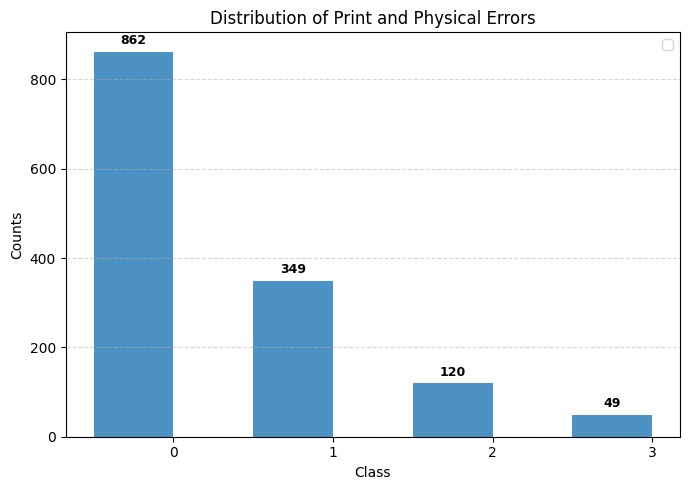

     file_prefix printError_physicalDefect  printError_physicalDefect_int
0     001_516_01                       0_0                              0
1     001_516_02                       0_1                              1
2     001_516_03                       0_0                              0
3     001_516_04                       0_0                              0
4     001_516_05                       0_0                              0
...          ...                       ...                            ...
1375  002_100_11                       0_1                              1
1376  002_100_12                       0_0                              0
1377  002_100_13                       0_0                              0
1378  002_100_14                       0_0                              0
1379  002_100_15                       1_0                              2

[1380 rows x 3 columns]


In [96]:
mapping = {
    "0_0": 0,
    "0_1": 1,
    "1_0": 2,
    "1_1": 3
}

df_MC["printError_physicalDefect_int"] = df_MC["printError_physicalDefect"].map(mapping)

# Count occurrences of each class
print_counts = df_MC["printError_physicalDefect_int"].value_counts().sort_index()

# Create the figure
fig, ax = plt.subplots(figsize=(7, 5))

# Define x positions for side-by-side bars
x = range(len(print_counts))  # same class positions (e.g. 0 and 1)
width = 0.5  # bar width

# Plot bars
bars1 = ax.bar([i - width/2 for i in x], print_counts, width, color='#1f77b4', alpha=0.8)

# Add text labels on top of bars
for bar in bars1:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, height + 10, f'{int(height)}',
            ha='center', va='bottom', fontsize=9, fontweight='bold')

# Customize axes
ax.set_xlabel("Class")
ax.set_ylabel("Counts")
ax.set_title("Distribution of Print and Physical Errors")
ax.set_xticks(x)
ax.set_xticklabels(print_counts.index)  # e.g. 0 and 1 only
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

print(df_MC)

### Binary annotations

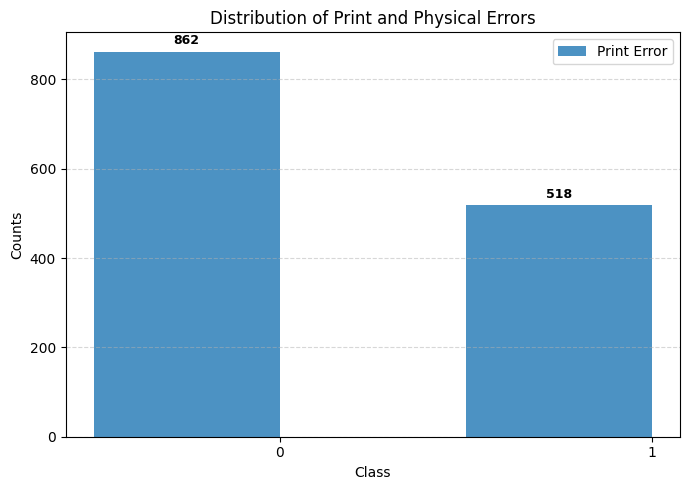

In [97]:
# Lista de strings a buscar en el nombre de la imagen

# Filtrar solo filas donde la segunda columna sea exactamente '0_0'
df_MC["binary"] = (df_MC["printError_physicalDefect_int"] != 0).astype(int)

# Count occurrences of each class
print_counts = df_MC["binary"].value_counts().sort_index()

# Create the figure
fig, ax = plt.subplots(figsize=(7, 5))

# Define x positions for side-by-side bars
x = range(len(print_counts))  # same class positions (e.g. 0 and 1)
width = 0.5  # bar width

# Plot bars
bars1 = ax.bar([i - width/2 for i in x], print_counts, width, label='Print Error', color='#1f77b4', alpha=0.8)

# Add text labels on top of bars
for bar in bars1:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, height + 10, f'{int(height)}',
            ha='center', va='bottom', fontsize=9, fontweight='bold')

# Customize axes
ax.set_xlabel("Class")
ax.set_ylabel("Counts")
ax.set_title("Distribution of Print and Physical Errors")
ax.set_xticks(x)
ax.set_xticklabels(print_counts.index)  # e.g. 0 and 1 only
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

### Data reduction

#### Unzip images inside google drive

In [98]:
extract_path = r"C:\Users\kartp\OneDrive\Documentos\IFRoS\1st semester\Machine Learning\Labs\FP\drive-download-20251113T114126Z-1-001\arrays"
# extract_path = '/content/drive/MyDrive/IFRoS/ML Labs/MILAN-dataset/arrays'

#### Define NPYImageDataset class to load the images

In [99]:
import os
import torch
from torch.utils.data import Dataset
import numpy as np

class NPYImageDataset(Dataset):
    def __init__(self, root_dir, names, labels, transform=None):
        """
        root_dir : Folder with .npy files
        names    : List like ['003_045_012', '002_047_12', ...]
        labels   : Array-like with class labels aligned with 'names'
        transform: torchvision transform
        """
        self.root_dir = root_dir
        self.names = names
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.names)

    def __getitem__(self, idx):
        name = self.names[idx]
        filename = f"{name}.npy"
        path = os.path.join(self.root_dir, filename)

        if not os.path.exists(path):
            raise FileNotFoundError(f"File not found: {path}")

        img = np.load(path)                          # (H, W, C)
        img = torch.from_numpy(img).permute(2, 0, 1).float()  # (C, H, W)

        if self.transform:
            img = self.transform(img)

        label = torch.tensor(self.labels[idx]).long()

        return img, label

class NPYImagePatchDataset(Dataset):
    def __init__(self, root_dir, names, labels,
                 patch_size=128, stride=61, transform=None):
        """
        names    : ['003_045_012', '002_047_12', ...]
        images: Tensor [N, 6, 310, 310]
        labels: Tensor [N]

        """
        self.root_dir = root_dir
        self.names = names
        self.labels = labels
        self.patch_size = patch_size
        self.stride = stride
        self.transform = transform

        # ---- Build patch index: (image_idx, x, y) ----
        self.patches = []

        for img_idx, name in enumerate(self.names):
            filename = f"{name}.npy"
            path = os.path.join(self.root_dir, filename)

            if not os.path.exists(path):
                raise FileNotFoundError(f"File not found: {path}")

            img = np.load(path)  # (H, W, C)
            H, W, _ = img.shape

            for y in range(0, H - patch_size + 1, stride):
                for x in range(0, W - patch_size + 1, stride):
                    self.patches.append((img_idx, x, y))

    def __len__(self):
        return len(self.patches)

    def __getitem__(self, idx):
        img_idx, x, y = self.patches[idx]

        name = self.names[img_idx]
        filename = f"{name}.npy"
        path = os.path.join(self.root_dir, filename)

        if not os.path.exists(path):
            raise FileNotFoundError(f"File not found: {path}")

        img = np.load(path)  # (H, W, C)
        img = torch.from_numpy(img).permute(2, 0, 1).float()  # (C, H, W)

        # ---- Extract PATCH ----
        patch = img[:, y:y+self.patch_size, x:x+self.patch_size]

        if self.transform:
            patch = self.transform(patch)

        label = torch.tensor(self.labels[img_idx]).long()

        return patch, label




In [100]:
all_names = df_MC["file_prefix"].values      # list of .npy filenames
all_labels = df_MC["binary"].values       # 0 / 1 labels

In [101]:
from sklearn.model_selection import train_test_split

# All indices as ints
indices = np.arange(len(all_names))

# Train set
train_idx, temp_idx = train_test_split(
    indices,
    test_size=0.30,
    stratify=all_labels,
    random_state=42
)

# Validation and test set
temp_labels = all_labels[temp_idx]
val_idx, test_idx = train_test_split(
    temp_idx,
    test_size=0.30,
    stratify=temp_labels,
    random_state=42
)

In [102]:
# Apply split to names and labels
train_names = all_names[train_idx]
val_names   = all_names[val_idx]
test_names  = all_names[test_idx]

train_labels = all_labels[train_idx]
val_labels   = all_labels[val_idx]
test_labels  = all_labels[test_idx]

#### Data transforming

In [103]:
import torchvision.transforms.v2 as transforms
import torch
import kornia.augmentation as K

def scale_image(x):
    return x / 255.0

train_transform = transforms.Compose([
    # Input comes as (C,H,W) torch tensor from NPY
    # Scale to [0,1]
    transforms.Lambda(scale_image),
    transforms.ToDtype(torch.float32),

    # Normalize all 6 channels
    transforms.Normalize(
        mean=[0.5]*6,
        std=[0.5]*6
    )
])

val_transform = transforms.Compose([
    transforms.Lambda(scale_image),
    transforms.ToDtype(torch.float32),

    transforms.Normalize(
        mean=[0.5]*6,
        std=[0.5]*6
    )
])

test_transform = transforms.Compose([
    transforms.Lambda(scale_image),
    transforms.ToDtype(torch.float32),

    transforms.Normalize(
        mean=[0.5]*6,
        std=[0.5]*6
    )
])


kornia_augment = torch.nn.Sequential(
    # K.RandomSharpness(sharpness=0.5, p=0.5),
    # K.RandomChannelShuffle(p=0.8),
    # K.RandomGamma(gamma = (0.8, 1.2),
    #               gain = (0.9, 1.1),
    #               p = 0.3, keepdim = True),
    # K.RandomVerticalFlip(p = 0.3),
    K.RandomHorizontalFlip(p = 0.3),
    K.RandomRotation(degrees = 2.0, p = 0.3),
    # K.RandomAffine(degrees = 0,
    #                translate = (0.05,0.05),
    #                scale = (0.95,1.05),
    #                p=0.4),
    K.RandomGaussianNoise(mean=0,
                          std=0.005,
                          p=0.15),
    # K.RandomGaussianBlur(kernel_size = (3, 3),
    #                      sigma = (0.1, 0.5),
    #                      p=0.2),
    K.RandomBrightness(brightness = (0.98, 1.02),
                       p = 0.2),
    K.RandomContrast(contrast = (0.98, 1.02),
                     p = 0.2),
    # K.RandomErasing(scale=(0.01, 0.05), p=0.35),
    # K.RandomErasing(scale=(0.005, 0.02), p=0.15)
)


In [104]:
train_dataset = NPYImagePatchDataset(
    patch_size=192, stride = 96,
    root_dir=extract_path,
    names=train_names,
    labels=train_labels,
    transform=train_transform
)

val_dataset = NPYImagePatchDataset(
    patch_size=192, stride = 96,
    root_dir=extract_path,
    names=val_names,
    labels=val_labels,
    transform=val_transform
)

test_dataset = NPYImageDataset(
    root_dir=extract_path,
    names=test_names,
    labels=test_labels,
    transform=test_transform
)

In [105]:
batch_size = 32

In [106]:
from torch.utils.data import DataLoader

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=0,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    # num_workers=4,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    # num_workers=4,
    pin_memory=True
)

#### Visuazlie a sample

label =  tensor(1)
Type: <class 'torch.Tensor'>
Shape: torch.Size([1, 6, 192, 192])
Label: tensor(1)


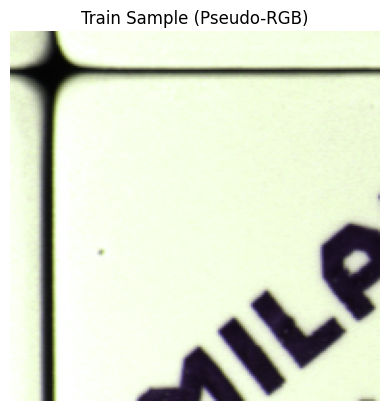

In [107]:
# Visualize ONE sample directly from the DATASET (no batching issues)

import matplotlib.pyplot as plt

# Get one raw sample from the dataset
img, label = train_dataset[0]
print("label = ",label)
img = kornia_augment(img)

print("Type:", type(img))
print("Shape:", img.shape)      # Expected: (1, 6, H, W)
print("Label:", label)

# Undo normalization for visualization
# Since you used: Normalize(mean=[0.5]*6, std=[0.5]*6)
img_vis = img[0, :3] * 0.5 + 0.5   # Take first 3 channels from the first image in batch as pseudo-RGB
img_vis = img_vis.clamp(0, 1)  # Safety clamp

# Show image
plt.imshow(img_vis.permute(1, 2, 0))
plt.title("Train Sample (Pseudo-RGB)")
plt.axis("off")
plt.show()

### Data splitting using multiclass

In [108]:
# def count_labels(loader):
#     count_0 = 0
#     count_1 = 0

#     for _, labels in loader:
#         labels = labels.cpu().numpy()
#         count_0 += (labels == 0).sum()
#         count_1 += (labels == 1).sum()

#     total = count_0 + count_1
#     perc_0 = 100 * count_0 / total
#     perc_1 = 100 * count_1 / total

#     return count_0, count_1, perc_0, perc_1


# # Train
# c0, c1, p0, p1 = count_labels(train_loader)
# print(f"\nTrain -> Class 0: {c0} ({p0:.2f}%) | Class 1: {c1} ({p1:.2f}%)")

# # Validation
# c0, c1, p0, p1 = count_labels(val_loader)
# print(f"Val   -> Class 0: {c0} ({p0:.2f}%) | Class 1: {c1} ({p1:.2f}%)")

# # Test
# c0, c1, p0, p1 = count_labels(test_loader)
# print(f"Test  -> Class 0: {c0} ({p0:.2f}%) | Class 1: {c1} ({p1:.2f}%)")


### Setting the Device

### Define structure

In [109]:
# Import pretrained model ResNet50
import torchvision.models as models
import numpy as np
import torch.nn as nn

# Hyperparameters
dropout_rate = 0.3
# learning_rate = 0.00005 #5e-5
# learning_rate = 0.0001 #1e-4
learning_rate = 1e-4

# weigth_decay = 1e-5
weigth_decay = 1e-4
num_classes = 2

# Imported model
imported_model = models.resnet50(pretrained=True, progress = True)

print(imported_model)

# Freeze layers
# frozen_layers = ("conv1", "layer1", "layer2")
# frozen_layers = ("layer2")
frozen_layers = ("")
for name, param in imported_model.named_parameters():
    if name.startswith(frozen_layers):
        param.requires_grad = False
    else:
        param.requires_grad = True

# Raplace first layer
# old_conv = imported_model.conv1
# imported_model.conv1 = nn.Conv2d( # Replace
#     in_channels=6,             # change from 3 to 6
#     out_channels=old_conv.out_channels,
#     kernel_size=old_conv.kernel_size,
#     stride=old_conv.stride,
#     padding=old_conv.padding,
#     bias=old_conv.bias
# )

old_weight = imported_model.conv1.weight  # [64, 3, 7, 7]
old_conv = imported_model.conv1
new_conv = nn.Conv2d(
    in_channels=6,             # change from 3 to 6
    out_channels=old_conv.out_channels,
    kernel_size=old_conv.kernel_size,
    stride=old_conv.stride,
    padding=old_conv.padding,
    bias=old_conv.bias
  )
with torch.no_grad():
    new_conv.weight[:, :3].copy_(old_weight)
    new_conv.weight[:, 3:].copy_(old_weight.clone())
imported_model.conv1 = new_conv


# Replace last classification layer with dropout
# imported_model.fc = nn.Sequential(
#     nn.Dropout(p=dropout_rate),   # 0.2
#     nn.Linear(512, num_classes)
# )
imported_model.fc = nn.Sequential(
    nn.Linear(2048, 1024),
    nn.BatchNorm1d(1024),
    nn.ReLU(),
    nn.Dropout(p=dropout_rate),
    nn.Linear(1024, 2)
)


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

### Train the model

### Train and Validation Fucntions

In [110]:
#train function
from sklearn.metrics import average_precision_score, f1_score
import torch.nn.functional as F
import numpy as np

def Train(model, train_loader, optimizer):
    model.train()

    running_loss = 0.0
    all_probs = []
    all_labels = []

    for i, (images, labels) in enumerate(train_loader):

        # Move data to GPU
        images = images.to(device)
        labels = labels.to(device)

        # Kornia data augmentation
        images = kornia_augment(images)

        # Forward pass
        outputs = model(images)
        loss = criterion(outputs, labels)

        # Backpropagation and optimization
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        # Convert logits → probability of positive class
        probs = F.softmax(outputs, dim=1)[:, 1]

        all_probs.extend(probs.detach().cpu().numpy())
        all_labels.extend(labels.detach().cpu().numpy())

    # Compute AUC-PR for the full epoch
    all_probs = np.array(all_probs)
    all_labels = np.array(all_labels)

    auc_pr = average_precision_score(all_labels, all_probs)
    avg_loss = running_loss / len(train_loader)

    # Binary predictions for F1
    preds = (all_probs >= 0.5).astype(int)

    # F1-score
    f1 = f1_score(all_labels, preds)

    return avg_loss, auc_pr, f1

#validation function
def Validate(model, val_loader):
    model.eval()

    running_loss = 0.0
    all_probs = []
    all_labels = []

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item()

            # Convert logits → probability of positive class
            probs = F.softmax(outputs, dim=1)[:, 1]

            all_probs.extend(probs.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    all_probs = np.array(all_probs)
    all_labels = np.array(all_labels)

    auc_pr = average_precision_score(all_labels, all_probs)
    avg_loss = running_loss / len(val_loader)

    # Binary predictions for F1
    preds = (all_probs >= 0.5).astype(int)

    # F1-score
    f1 = f1_score(all_labels, preds)

    return avg_loss, auc_pr, f1

In [111]:
# Optimizer and Criterion
def compute_class_stats_from_loader(loader):
    total_per_class = torch.zeros(2)

    for _, labels in loader:
        for c in [0, 1]:
            total_per_class[c] += (labels == c).sum()

    N0 = int(total_per_class[0].item())  # non-defective
    N1 = int(total_per_class[1].item())  # defective

    return N0, N1
# Define device foor runtime
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Class distribution
N0, N1 = compute_class_stats_from_loader(train_loader)
print("Non-defective:", N0)
print("Defective:", N1)

# Calculate the weights
beta = 0.999
w0 = (1 - beta) / (1 - beta**N0)
w1 = (1 - beta) / (1 - beta**N1)
# weights = torch.tensor([w0, w1]).to(device)
weights = torch.tensor([1.0, 1.1]).to(device)
criterion = nn.CrossEntropyLoss(weight=weights
                                # , label_smoothing=0.05
                                )

# Define optimizer
# optimizer = torch.optim.AdamW(imported_model.parameters(), lr=learning_rate, weight_decay=weigth_decay) # RESNET34
optimizer = torch.optim.AdamW( # RESNET50
    [
        {"params": imported_model.conv1.parameters(), "lr": 1e-4},
        {"params": imported_model.layer1.parameters(), "lr": 1e-4},
        {"params": imported_model.layer2.parameters(), "lr": 2e-4},
        {"params": imported_model.layer3.parameters(), "lr": 3e-4},
        {"params": imported_model.layer4.parameters(), "lr": 3e-4},
        {"params": imported_model.fc.parameters(),     "lr": 4e-4},
    ],
    weight_decay=1.5e-4
)

# Parse model to the GPU
imported_model = imported_model.to(device)

Non-defective: 2412
Defective: 1452


In [112]:
print(w0, w1)

0.0010983310961907992 0.0013053664778032864


In [113]:
num_epochs = 90
patience = 25
min_delta = 2e-3

best_val_aucpr = 0.0
epochs_no_improve = 0
best_model_state = None

In [114]:
print(imported_model)

ResNet(
  (conv1): Conv2d(6, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [115]:
# History containers
train_losses = []
val_losses = []
train_aucprs = []
val_aucprs = []
train_f1s = []
val_f1s = []

best_val_aucpr = 0.0
best_epoch = 0
epochs_no_improve = 0

# Scheduler
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=num_epochs
)

for epoch in range(num_epochs):
    train_loss, train_aucpr, train_f1 = Train(imported_model, train_loader, optimizer)
    val_loss, val_aucpr, val_f1 = Validate(imported_model, val_loader)

    # Store values
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_aucprs.append(train_aucpr)
    val_aucprs.append(val_aucpr)
    train_f1s.append(train_f1)
    val_f1s.append(val_f1)

    print(
        f"Epoch [{epoch+1}/{num_epochs}] | "
        f"Train Loss: {train_loss:.4f} | Train AUC-PR: {train_aucpr:.4f} | Train F1: {train_f1:.4f} || "
        f"Val Loss: {val_loss:.4f} | Val AUC-PR: {val_aucpr:.4f} | Val F1: {val_f1:.4f}"
    )

    # CORRECT early stopping + TRUE best model tracking
    if val_aucpr > best_val_aucpr + min_delta:
        best_val_aucpr = val_aucpr
        best_epoch = epoch + 1
        epochs_no_improve = 0
        best_model_state = imported_model.state_dict()
    else:
        epochs_no_improve += 1
        print(f" EarlyStopping counter: {epochs_no_improve}/{patience}")

    if epochs_no_improve >= patience:
        print("Early stopping triggered.")
        break

    scheduler.step()

# Restore true best model
imported_model.load_state_dict(best_model_state)
print(
    f"Best model restored (Epoch = {best_epoch} | Val AUC-PR = {best_val_aucpr:.4f})"
)


Epoch [1/90] | Train Loss: 0.7353 | Train AUC-PR: 0.4723 | Train F1: 0.4372 || Val Loss: 0.6204 | Val AUC-PR: 0.5704 | Val F1: 0.4092
Epoch [2/90] | Train Loss: 0.6487 | Train AUC-PR: 0.5474 | Train F1: 0.4769 || Val Loss: 0.6307 | Val AUC-PR: 0.5865 | Val F1: 0.5200
Epoch [3/90] | Train Loss: 0.6312 | Train AUC-PR: 0.5731 | Train F1: 0.4871 || Val Loss: 0.6618 | Val AUC-PR: 0.5116 | Val F1: 0.4526
 EarlyStopping counter: 1/25
Epoch [4/90] | Train Loss: 0.6236 | Train AUC-PR: 0.5937 | Train F1: 0.4961 || Val Loss: 0.6231 | Val AUC-PR: 0.5785 | Val F1: 0.4461
 EarlyStopping counter: 2/25
Epoch [5/90] | Train Loss: 0.6091 | Train AUC-PR: 0.6115 | Train F1: 0.5008 || Val Loss: 0.6716 | Val AUC-PR: 0.5851 | Val F1: 0.5907
 EarlyStopping counter: 3/25
Epoch [6/90] | Train Loss: 0.6149 | Train AUC-PR: 0.6075 | Train F1: 0.5116 || Val Loss: 0.6284 | Val AUC-PR: 0.6221 | Val F1: 0.5938
Epoch [7/90] | Train Loss: 0.6073 | Train AUC-PR: 0.6237 | Train F1: 0.5211 || Val Loss: 0.6199 | Val AUC-PR:

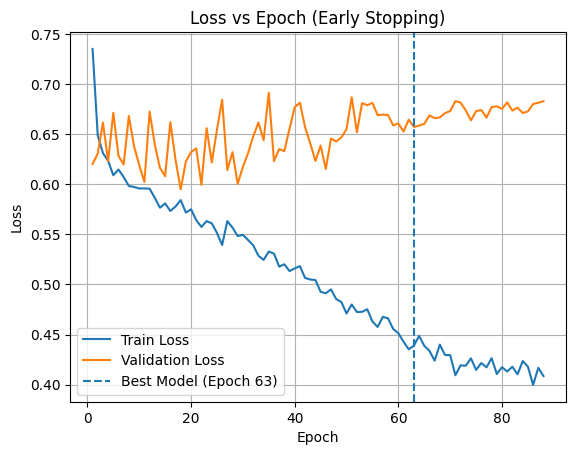

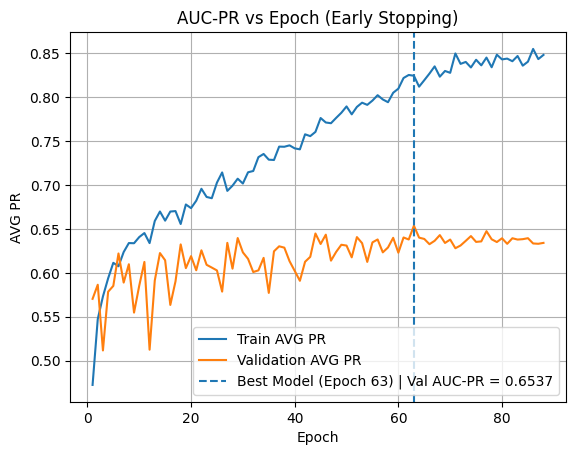

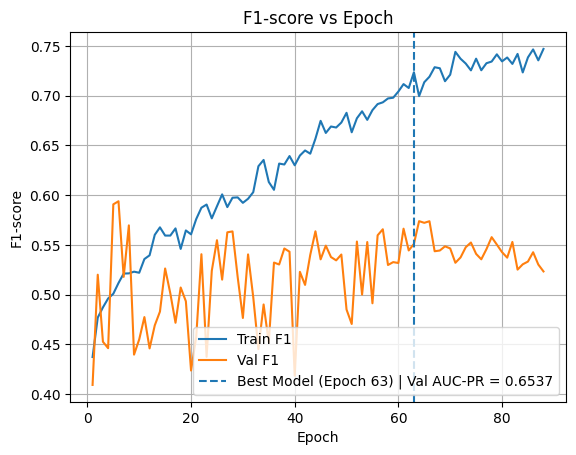

In [123]:
epochs = list(range(1, len(train_losses) + 1))

# -------- LOSS PLOT --------
plt.figure()
plt.plot(epochs, train_losses, label='Train Loss')
plt.plot(epochs, val_losses, label='Validation Loss')
plt.axvline(
    best_epoch,
    linestyle='--',
    label=f'Best Model (Epoch {best_epoch})'
)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss vs Epoch (Early Stopping)')
plt.legend()
plt.grid(True)
plt.show()

# -------- AUC-PR PLOT --------
plt.figure()
plt.plot(epochs, train_aucprs, label='Train AVG PR')
plt.plot(epochs, val_aucprs, label='Validation AVG PR')
plt.axvline(
    best_epoch,
    linestyle='--',
    label=f'Best Model (Epoch {best_epoch}) | Val AUC-PR = {best_val_aucpr:.4f}'
)
plt.xlabel('Epoch')
plt.ylabel('AVG PR')
plt.title('AUC-PR vs Epoch (Early Stopping)')
plt.legend()
plt.grid(True)
plt.show()

# -------- F1 SCORE PLOT --------
plt.figure()
plt.plot(epochs, train_f1s, label="Train F1")
plt.plot(epochs, val_f1s, label="Val F1")
plt.axvline(
    best_epoch,
    linestyle='--',
    label=f'Best Model (Epoch {best_epoch}) | Val AUC-PR = {best_val_aucpr:.4f}'
)
plt.xlabel("Epoch")
plt.ylabel("F1-score")
plt.title("F1-score vs Epoch")
plt.legend()
plt.grid(True)
plt.show()


In [124]:
class FullImagePatchWrapper(torch.nn.Module):
    """
    Takes an input image of 310x310, breaks it into patches of 128x128, and parses them into the patch model to identify any defect.
    The outcome of the image will be the concensus of all the patches. If any patch is defective, the image is defective.
    """
    def __init__(self, patch_model, patch_size=128, stride=61):
        super().__init__()
        self.patch_model = patch_model
        self.patch_size = patch_size
        self.stride = stride

    def forward(self, img):
        """
        img: [1, 6, 310, 310]
        returns: scalar probability of defect (after MAX voting)
        """
        _, _, H, W = img.shape
        patch_probs = []

        for y in range(0, H - self.patch_size + 1, self.stride):
            for x in range(0, W - self.patch_size + 1, self.stride):
                patch = img[:, :, y:y+self.patch_size, x:x+self.patch_size]
                logits = self.patch_model(patch)
                prob = torch.softmax(logits, dim=1)[:, 1]  # defect prob
                patch_probs.append(prob)

        patch_probs = torch.stack(patch_probs)  # [num_patches, 1]
        final_prob = patch_probs.max()          # ✅ MAX voting for defects

        return final_prob.unsqueeze(0)          # shape [1]


In [125]:
# Wrapped model that devides the image into patches and applies the model to each one
wrapped_model = FullImagePatchWrapper(
    imported_model,
    patch_size=128,
    stride=64
).to(device)

Average Precision (AP): 0.7060
PR-AUC (Trapezoidal):   0.7035
Best F1 Score:          0.6261
Best Threshold:        0.9342
Labels distribution:    [78 47]


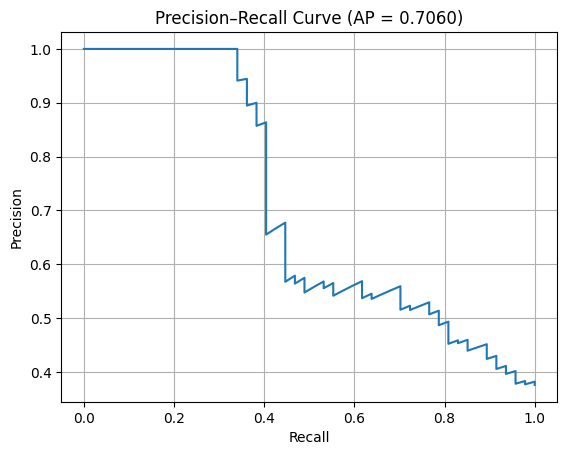

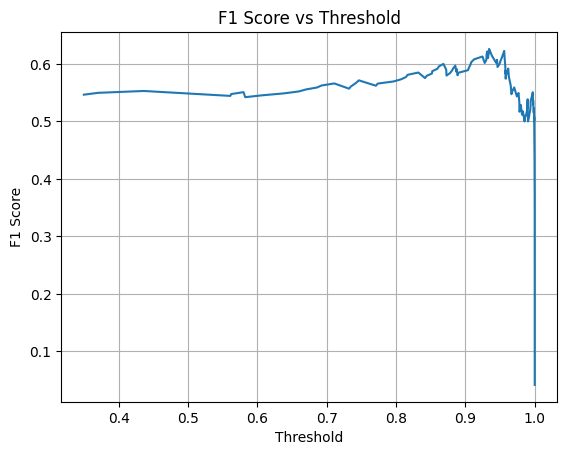

In [126]:
from sklearn.metrics import average_precision_score, precision_recall_curve, auc
import numpy as np
import matplotlib.pyplot as plt

wrapped_model.eval()
all_probs = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)      # [B, 6, 310, 310]
        labels = labels.to(device)      # [B]

        B = images.shape[0]

        for i in range(B):
            img = images[i].unsqueeze(0)      # ✅ [1, 6, 310, 310]
            label = labels[i].item()          # ✅ scalar

            prob = wrapped_model(img).item()  # ✅ scalar probability

            all_probs.append(prob)
            all_labels.append(label)

# Convert to numpy
all_probs = np.array(all_probs)
all_labels = np.array(all_labels)

# ============================================================
# ✅ METRICS
# ============================================================

# ✅ 1. Average Precision (true AUC-PR)
ap_score = average_precision_score(all_labels, all_probs)

# ✅ 2. Precision–Recall curve
precision, recall, thresholds = precision_recall_curve(all_labels, all_probs)

# ✅ 3. PR-AUC (geometric area)
pr_auc = auc(recall, precision)

# ✅ 4. F1 vs threshold
f1_scores = 2 * (precision * recall) / (precision + recall + 1e-8)

best_idx = np.argmax(f1_scores)
best_f1 = f1_scores[best_idx]
best_threshold = thresholds[best_idx] if best_idx < len(thresholds) else 0.5

# ============================================================
# ✅ PRINT RESULTS
# ============================================================

print(f"Average Precision (AP): {ap_score:.4f}")
print(f"PR-AUC (Trapezoidal):   {pr_auc:.4f}")
print(f"Best F1 Score:          {best_f1:.4f}")
print(f"Best Threshold:        {best_threshold:.4f}")
print("Labels distribution:   ", np.bincount(all_labels.astype(int)))

# ============================================================
# ✅ PLOTS
# ============================================================

# ---- Precision–Recall Curve ----
plt.figure()
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title(f"Precision–Recall Curve (AP = {ap_score:.4f})")
plt.grid(True)
plt.show()

# ---- F1 vs Threshold Curve ----
plt.figure()
plt.plot(thresholds, f1_scores[:-1])
plt.xlabel("Threshold")
plt.ylabel("F1 Score")
plt.title("F1 Score vs Threshold")
plt.grid(True)
plt.show()


## Saving the model

In [120]:
# !pip install torch==2.2.0 torchvision==0.17.0 torchaudio==2.2.0 --index-url https://download.pytorch.org/whl/cu118
!pip install onnx onnxruntime onnxscript


  Using cached onnxruntime-1.23.2-cp311-cp311-win_amd64.whl.metadata (5.3 kB)
  Using cached onnxscript-0.5.6-py3-none-any.whl.metadata (13 kB)
  Using cached onnx_ir-0.1.12-py3-none-any.whl.metadata (3.2 kB)
Using cached onnxruntime-1.23.2-cp311-cp311-win_amd64.whl (13.5 MB)
Using cached onnxscript-0.5.6-py3-none-any.whl (683 kB)
Using cached onnx_ir-0.1.12-py3-none-any.whl (129 kB)

   ---------------------------------------- 0/3 [onnxruntime]



ERROR: Could not install packages due to an OSError: [WinError 5] Access is denied: 'C:\\Users\\kartp\\OneDrive\\Documentos\\IFRoS\\1st semester\\Machine Learning\\.ML_venv\\Lib\\site-packages\\onnxruntime\\capi\\onnxruntime_providers_shared.dll'
Check the permissions.



In [121]:
print(torch.__version__)

2.10.0.dev20251210+cu128


In [128]:
import torch
import torch.onnx

dummy_input = torch.rand(1, 6, 310, 310).to(device)

wrapped_model.eval()
torch.onnx.export(
    wrapped_model,
    dummy_input,                     # still use (1,6,H,W)
    "wrapped_model_1.onnx",
    opset_version=13,
    input_names=["x"],
    output_names=["linear"],
    dynamic_axes={
        "x": {0: "batch_size"},      # ✅ dynamic batch
        "linear": {0: "batch_size"}  # ✅ dynamic output batch
    }
)

W1210 23:37:04.079000 36720 Lib\site-packages\torch\onnx\_internal\exporter\_compat.py:125] Setting ONNX exporter to use operator set version 18 because the requested opset_version 13 is a lower version than we have implementations for. Automatic version conversion will be performed, which may not be successful at converting to the requested version. If version conversion is unsuccessful, the opset version of the exported model will be kept at 18. Please consider setting opset_version >=18 to leverage latest ONNX features


[torch.onnx] Obtain model graph for `FullImagePatchWrapper([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `FullImagePatchWrapper([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decomposition...
[torch.onnx] Run decomposition... ✅
[torch.onnx] Translate the graph into ONNX...


The model version conversion is not supported by the onnxscript version converter and fallback is enabled. The model will be converted using the onnx C API (target version: 13).


[torch.onnx] Translate the graph into ONNX... ✅


Failed to convert the model to the target version 13 using the ONNX C API. The model was not modified
Traceback (most recent call last):
  File "c:\Users\kartp\OneDrive\Documentos\IFRoS\1st semester\Machine Learning\.ML_venv\Lib\site-packages\onnxscript\version_converter\__init__.py", line 127, in call
    converted_proto = _c_api_utils.call_onnx_api(
                      ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\kartp\OneDrive\Documentos\IFRoS\1st semester\Machine Learning\.ML_venv\Lib\site-packages\onnxscript\version_converter\_c_api_utils.py", line 65, in call_onnx_api
    result = func(proto)
             ^^^^^^^^^^^
  File "c:\Users\kartp\OneDrive\Documentos\IFRoS\1st semester\Machine Learning\.ML_venv\Lib\site-packages\onnxscript\version_converter\__init__.py", line 122, in _partial_convert_version
    return onnx.version_converter.convert_version(
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\kartp\OneDrive\Documentos\IFRoS\1st semester\Machine Learning

Applied 541 of general pattern rewrite rules.


ONNXProgram(
    model=
        <
            ir_version=10,
            opset_imports={'': 18},
            producer_name='pytorch',
            producer_version='2.10.0.dev20251210+cu128',
            domain=None,
            model_version=None,
        >
        graph(
            name=main_graph,
            inputs=(
                %"x"<FLOAT,[batch_size,6,310,310]>
            ),
            outputs=(
                %"linear"<FLOAT,[1]>
            ),
            initializers=(
                %"patch_model.bn1.weight"<FLOAT,[64]>{TorchTensor(...)},
                %"patch_model.bn1.bias"<FLOAT,[64]>{TorchTensor(...)},
                %"patch_model.layer1.0.bn1.weight"<FLOAT,[64]>{TorchTensor(...)},
                %"patch_model.layer1.0.bn1.bias"<FLOAT,[64]>{TorchTensor(...)},
                %"patch_model.layer1.0.bn2.weight"<FLOAT,[64]>{TorchTensor(...)},
                %"patch_model.layer1.0.bn2.bias"<FLOAT,[64]>{TorchTensor(...)},
                %"patch_model.layer1.0.bn3

## Testing the model

In [ ]:
import onnx

# Load the ONNX model
loaded_model = onnx.load("model_v5.onnx")

# Check that the IR is well formed
onnx.checker.check_model(loaded_model)

# Print a human readable representation of the graph
print(onnx.helper.printable_graph(loaded_model.graph))

print(loaded_model.graph.input[0].type.tensor_type.shape)

In [ ]:
import onnx
from onnx import numpy_helper
import onnxruntime as ort
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import average_precision_score, precision_recall_curve

# ---------- 1) PATCH THE ONNX RESHAPE CONSTANT ----------
onnx_path_in = "model_v5.onnx"      # your current ONNX
onnx_path_out = "model_v5.onnx"

model = onnx.load(onnx_path_in)

# We know the Reshape uses ['mean', 'val_334'], so we patch 'val_334'
target_init_name = "val_334"

found = False
for i, init in enumerate(model.graph.initializer):
    if init.name == target_init_name:
        arr = numpy_helper.to_array(init).astype(np.int64)
        print("Original reshape shape:", arr)   # likely [  1 512]
        arr[0] = -1                             # make batch dynamic: [-1, 512]
        new_init = numpy_helper.from_array(arr, name=target_init_name)
        model.graph.initializer[i].CopyFrom(new_init)
        print("Patched reshape shape:", arr)
        found = True
        break

if not found:
    raise RuntimeError(f"Initializer '{target_init_name}' not found in ONNX graph")

onnx.save(model, onnx_path_out)
print(f"✅ Saved patched model as {onnx_path_out}")

# ---------- 2) CREATE ONNX RUNTIME SESSION ----------
ort_session = ort.InferenceSession(
    onnx_path_out,
    providers=["CUDAExecutionProvider", "CPUExecutionProvider"]
)

input_name = ort_session.get_inputs()[0].name
output_name = ort_session.get_outputs()[0].name

print("ONNX Input Name :", input_name)
print("ONNX Output Name:", output_name)

# ---------- 3) RUN INFERENCE ON TEST LOADER (BATCHED, e.g. batch_size=10) ----------
all_probs = []
all_labels = []

for images, labels in test_loader:
    images_np = images.cpu().numpy()   # (B, 6, 310, 310)
    labels_np = labels.cpu().numpy()

    outputs = ort_session.run(
        [output_name],
        {input_name: images_np}
    )[0]  # (B, 2)

    # Softmax over class dim
    exp_logits = np.exp(outputs)
    probs = exp_logits / exp_logits.sum(axis=1, keepdims=True)
    probs_pos = probs[:, 1]  # positive class

    all_probs.extend(probs_pos)
    all_labels.extend(labels_np)

all_probs = np.array(all_probs)
all_labels = np.array(all_labels)

# ---------- 4) METRICS & PLOT ----------
auc_pr = average_precision_score(all_labels, all_probs)
print(f"\n✅ AUC-PR (ONNX, batched): {auc_pr:.4f}")

precision, recall, thresholds = precision_recall_curve(all_labels, all_probs)

plt.figure()
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title(f"Precision-Recall Curve (AUC = {auc_pr:.4f})")
plt.grid(True)
plt.show()

print("\nLabels distribution:", np.bincount(all_labels.astype(int)))
print("Probabilities min/max:", all_probs.min(), all_probs.max())
print("Total samples:", len(all_probs))
